<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-III/blob/main/Clase%2001/RedesNeuronales_Regresion_Estaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌡️ Predicción de Temperatura con Redes Neuronales (Regresión)


## 📥 Carga de datos

In [ ]:
import numpy
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#se importa el set de datos
url = 'https://raw.githubusercontent.com/Jorge-Ruiz-Troccoli/Data-Science-III/refs/heads/main/Clase%2001/base_datos_estaciones_met_V3_train.csv?token=GHSAT0AAAAAAD54NQSV5ANS7XDNQAXSYAZQ2SPVZGA'
df_dataset1= pd.read_csv(url, sep=",")
df_dataset1.columns

## 🧹 Preprocesamiento: features y escalado

In [ ]:
x_dataset1= df_dataset1[[ 'Temp_Las Varas AgriculturaCba',
        'Temp_San Miguel - Establecimiento Don Luis']]
y_dataset1= df_dataset1["Temp_Alicia AgriculturaCba"]

In [ ]:
#Estandarizo las features, las redes son muy sensibles a datos no escalados.
scaler = StandardScaler()
x_scaler_dataset1= scaler.fit_transform(x_dataset1)


## ✂️ Train / Test split

In [ ]:
#Separo los datos de "train" en entrenamiento y prueba "test" para probar los algoritmos
x_train, x_test, y_train, y_test = train_test_split(x_scaler_dataset1, y_dataset1, test_size=0.2, random_state=42)

In [ ]:
len(x_train)


Si vemos un ejemplo similar, podemos observar  la estructura de una red neuronal multicapa (una capa de entrada con cinco nodos, dos capas ocultas de cuatro y tres nodos respectivamente, y una capa de salida de dos nodos: 5-4-3-2).

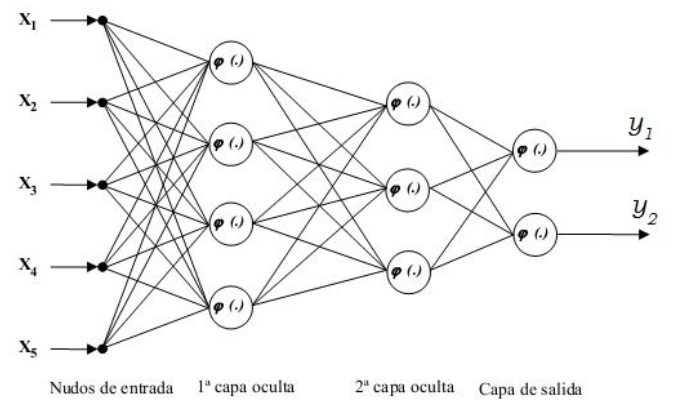

## 🧠 Arquitectura del modelo

In [ ]:
#Defino la función neuronal
def define_model():

    keras.backend.clear_session()
    # se eliminan todos los modelos y operaciones creados en la sesión actual, libera memoria y permita una construcción en limpio
    model = keras.models.Sequential()
    # se utiliza para crear un modelo secuencial en deep learning. Un modelo secuencial es una pila de capas donde la salida de una capa es la entrada de la siguiente capa.




    # 2 capas ocultas con función de activación relu, podemos usar tambien linear.
    model.add(keras.layers.Dense(8, input_dim=2, kernel_initializer='normal', activation='relu'))
    model.add(keras.layers.Dense(4,  kernel_initializer='normal', activation='relu'))




    # Capa de salida
    model.add(keras.layers.Dense(1,kernel_initializer='normal', activation='linear'))
    model.compile(loss='mse', metrics=['mse', 'mae'], optimizer="rmsprop")

    # kernel_initializer='normal', los pesos de las capas densas se inicializan aleatoriamente según la distribución normal.
    # La función de pérdida (loss function) se utiliza durante el entrenamiento para optimizar los pesos del modelo
    # El optimizador "rmsprop" se utiliza para ajustar los pesos del modelo durante el entrenamiento.
    # Las métricas de evaluación "mse" y "mae" para monitorear durante el entrenamiento

    return model





Funciones de activación:

ReLU (Rectified Linear Unit): La función ReLU asigna cero a todos los valores negativos y mantiene los valores positivos sin cambios. Es ampliamente utilizada debido a su eficiencia de cálculo y su capacidad para introducir no linealidades en el modelo.

Sigmoid: La función sigmoid (o logística) toma cualquier valor real y lo comprime en un rango entre 0 y 1. Se utiliza comúnmente en problemas de clasificación binaria para obtener probabilidades de clasificación.

Tanh (Tangente hiperbólica): La función tanh es similar a la sigmoid, pero su rango es entre -1 y 1. También se utiliza en problemas de clasificación y tiene la propiedad de ser simétrica alrededor del origen.

Softmax: La función softmax se utiliza en problemas de clasificación multiclase para obtener probabilidades de clasificación para cada clase. Toma un vector de valores reales y los normaliza para sumar 1, lo que permite interpretar los valores resultantes como probabilidades.

Linear (Lineal): La función lineal simplemente pasa los valores de entrada sin realizar ninguna transformación no lineal. Se utiliza en casos donde se desea una salida lineal sin aplicar ninguna función de activación específica.

## 🏋️ Entrenamiento

In [ ]:
model = define_model()

#Early es un buen metodo de regularizacion, en patience aplicamos un 30 para que al menos tengan que pasar 30 epochs antes de hacer una parada.
early = keras.callbacks.EarlyStopping(patience=15, monitor='val_loss', restore_best_weights=True)
history = model.fit(epochs=20, batch_size=32, x=x_train, y=y_train, validation_data=(x_test, y_test), callbacks=[early])




val_loss es el valor de la función de pérdida (loss) calculado sobre el conjunto de validación, no sobre el de entrenamiento.

Si ves que loss sigue bajando pero val_loss empieza a subir o se estanca, tu red está memorizando los datos de entrenamiento en vez de generalizar.

Batch Size: este es el número de ejemplos que se introducen en la red para que entrene de cada vez. Si el número es pequeño, significa que la red tiene en memoria poca cantidad de datos, y entrena más rápido. Sin embargo, es posible que no aprenda las características y detalles que pueden ser significativos en la predicción. Si es grande, ocurre al contrario: es más probable que tenga en cuenta los casos más importantes a la hora de aprender, pero entrena más lento.

Epoch: este es el número de veces que se van a pasar cada ejemplo de entrenamiento por la red.

## 📊 Evaluación del modelo

In [ ]:


# se puede observar como el error de entrenamiento va disminuyendo, pero el de validación aumenta. Un claro sobreajuste
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error')
  plt.plot(hist['epoch'], hist['mae'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mae'],
           label = 'Val Error')
  plt.ylim([0,1])
  plt.legend()

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Square Error')
  plt.plot(hist['epoch'], hist['mse'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mse'],
           label = 'Val Error')
  plt.ylim([0,1])
  plt.legend()
  plt.show()


plot_history(history)

In [ ]:
# Predicciones sobre TEST (datos que el modelo no vio en el entrenamiento)
y_pred_test = model.predict(x_test)

# Predicciones sobre TRAIN, para comparar y detectar overfitting
y_pred_train = model.predict(x_train)

### 📐 Métrica final: RMSE

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE en TEST: mide qué tan bien generaliza el modelo a datos nuevos
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5

# RMSE en TRAIN: si es mucho más bajo que el de test, hay overfitting
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5

print("RMSE train:", rmse_train)
print("RMSE test :", rmse_test)